# Creator Policy Impact Simulator — Notebook 2: Policy Simulation Engine
**Author:** Ajay Singh Rawat

---
## This is the core of the project

This notebook answers the exact question the YPP T&S Analytics team asks before any policy change:

> **"If we change the eligibility threshold from X to Y, how many creators are affected, which segments, and is the impact statistically significant?"**

We simulate three policy scenarios and measure:
- How many creators gain / lose eligibility (the north star metric impact)
- Which creator tiers are most affected (segment analysis)
- Whether the impact is statistically significant (chi-square test — same as your Anblicks work)
- What the precision/recall tradeoff looks like at different thresholds
- False positive rate — legitimate creators wrongly excluded (the cost of over-enforcement)

## The three policy scenarios we simulate

| Scenario | Threshold | What it represents |
|---|---|---|
| Current policy (baseline) | Score >= 0.35 | Existing YPP-like standard |
| Tighter policy | Score >= 0.50 | New policy raising the bar |
| Looser policy | Score >= 0.25 | Expanded access for smaller creators |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')


creators = pd.read_csv('/Applications/Studyyy/Projects/Trust and Safety/Creator policy impact simulator/data/processed/creator_features.csv')

TIER_ORDER = ['Micro (<10K)', 'Small (10K–100K)', 'Mid (100K–1M)',
              'Large (1M–10M)', 'Mega (10M+)']
creators['creator_tier'] = pd.Categorical(
    creators['creator_tier'], categories=TIER_ORDER, ordered=True
)

print(f'Loaded {len(creators):,} creators')
print(f'Score range: {creators["eligibility_score"].min():.3f} – {creators["eligibility_score"].max():.3f}')

Loaded 2,153 creators
Score range: 0.003 – 0.626


## 1. Define Policy Scenarios

In [2]:
POLICIES = {
    'Current policy':  {'threshold': 0.35, 'color': '#2E86AB', 'linestyle': '-'},
    'Tighter policy':  {'threshold': 0.50, 'color': '#E84855', 'linestyle': '--'},
    'Looser policy':   {'threshold': 0.25, 'color': '#2A9D8F', 'linestyle': ':'},
}

for name, cfg in POLICIES.items():
    col = f'eligible_{name.split()[0].lower()}'
    creators[col] = (creators['eligibility_score'] >= cfg['threshold']).astype(int)
    rate = creators[col].mean()
    count = creators[col].sum()
    print(f'{name} (threshold={cfg["threshold"]}): {count:,} eligible ({rate:.1%})')

Current policy (threshold=0.35): 260 eligible (12.1%)
Tighter policy (threshold=0.5): 39 eligible (1.8%)
Looser policy (threshold=0.25): 828 eligible (38.5%)


## 2. North Star Metric — Eligibility Rate by Policy

**This is the headline number** — the metric YPP leadership tracks.

In [3]:
# North star summary
summary = []
for name, cfg in POLICIES.items():
    col = f'eligible_{name.split()[0].lower()}'
    eligible = creators[col].sum()
    rate     = creators[col].mean()
    summary.append({
        'Policy':           name,
        'Threshold':        cfg['threshold'],
        'Eligible creators':eligible,
        'Eligibility rate': f'{rate:.1%}',
        'vs. current':      '—' if name == 'Current policy' else
                            f"+{eligible - creators['eligible_current'].sum():,}" if eligible > creators['eligible_current'].sum()
                            else f"{eligible - creators['eligible_current'].sum():,}"
    })

summary_df = pd.DataFrame(summary)
print('North Star Metric — Eligibility Rate by Policy')
print('=' * 60) #print the '=' sign 60 times in a row.
print(summary_df.to_string(index=False))

North Star Metric — Eligibility Rate by Policy
        Policy  Threshold  Eligible creators Eligibility rate vs. current
Current policy       0.35                260            12.1%           —
Tighter policy       0.50                 39             1.8%        -221
 Looser policy       0.25                828            38.5%        +568


## 3. Statistical Significance — Chi-Square Test

**T&S question:** Is the difference in eligibility rates between the current and proposed policy real, or just noise?

In [4]:
print('Statistical Significance Testing — Chi-Square')
print('=' * 60)
print('Null hypothesis: The policy change does NOT significantly')
print('affect the distribution of eligible vs ineligible creators.\n')

baseline_col = 'eligible_current'

for name, cfg in POLICIES.items():
    if name == 'Current policy':
        continue

    col = f'eligible_{name.split()[0].lower()}'

    # Contingency table: rows = policy, cols = eligible/not eligible
    current_yes  = creators[baseline_col].sum()
    current_no   = len(creators) - current_yes
    proposed_yes = creators[col].sum()
    proposed_no  = len(creators) - proposed_yes

    contingency = np.array([
        [current_yes,  current_no],
        [proposed_yes, proposed_no]
    ])

    chi2, p_value, dof, expected = chi2_contingency(contingency)

    # Effect size (Cramer's V)
    n = contingency.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

    sig = '*** SIGNIFICANT' if p_value < 0.001 else \
          '** SIGNIFICANT'  if p_value < 0.01  else \
          '* SIGNIFICANT'   if p_value < 0.05  else \
          'Not significant'

    print(f'Current vs {name}:')
    print(f'  Chi-square: {chi2:.2f}')
    print(f'  p-value:    {p_value:.4f}  →  {sig}')
    print(f"  Effect size (Cramer's V): {cramers_v:.4f}")
    print(f'  Interpretation: The policy change is {"" if p_value < 0.05 else "NOT "}'
          f'statistically meaningful — it would affect a real, non-random segment of creators.\n')

Statistical Significance Testing — Chi-Square
Null hypothesis: The policy change does NOT significantly
affect the distribution of eligible vs ineligible creators.

Current vs Tighter policy:
  Chi-square: 173.95
  p-value:    0.0000  →  *** SIGNIFICANT
  Effect size (Cramer's V): 0.2010
  Interpretation: The policy change is statistically meaningful — it would affect a real, non-random segment of creators.

Current vs Looser policy:
  Chi-square: 395.39
  p-value:    0.0000  →  *** SIGNIFICANT
  Effect size (Cramer's V): 0.3030
  Interpretation: The policy change is statistically meaningful — it would affect a real, non-random segment of creators.



## 4. Segment Analysis — Which Creator Tiers Are Most Affected?

**T&S insight:** Policy changes don't affect all creators equally. A tighter policy might disproportionately exclude small/micro creators while barely touching mega creators. This is the equity analysis the policy team needs before going live.

In [5]:
# Eligibility rate by tier under each policy
tier_analysis = creators.groupby('creator_tier', observed=True).agg(
    total_creators   = ('channel_title', 'count'),
    eligible_current = ('eligible_current', 'mean'),
    eligible_tighter = ('eligible_tighter', 'mean'),
    eligible_looser  = ('eligible_looser',  'mean'),
).reset_index()

tier_analysis['impact_tighter'] = (
    tier_analysis['eligible_tighter'] - tier_analysis['eligible_current']
).round(3)
tier_analysis['impact_looser'] = (
    tier_analysis['eligible_looser'] - tier_analysis['eligible_current']
).round(3)

print('Eligibility Rate by Creator Tier — Policy Comparison')
print(tier_analysis[[
    'creator_tier', 'total_creators',
    'eligible_current', 'eligible_tighter', 'eligible_looser',
    'impact_tighter', 'impact_looser'
]].to_string(index=False))

Eligibility Rate by Creator Tier — Policy Comparison
    creator_tier  total_creators  eligible_current  eligible_tighter  eligible_looser  impact_tighter  impact_looser
    Micro (<10K)              85          0.000000          0.000000         0.000000           0.000          0.000
Small (10K–100K)             230          0.000000          0.000000         0.008696           0.000          0.009
   Mid (100K–1M)             457          0.000000          0.000000         0.039387           0.000          0.039
  Large (1M–10M)             687          0.023290          0.000000         0.298399          -0.023          0.275
     Mega (10M+)             694          0.351585          0.056196         0.868876          -0.295          0.517


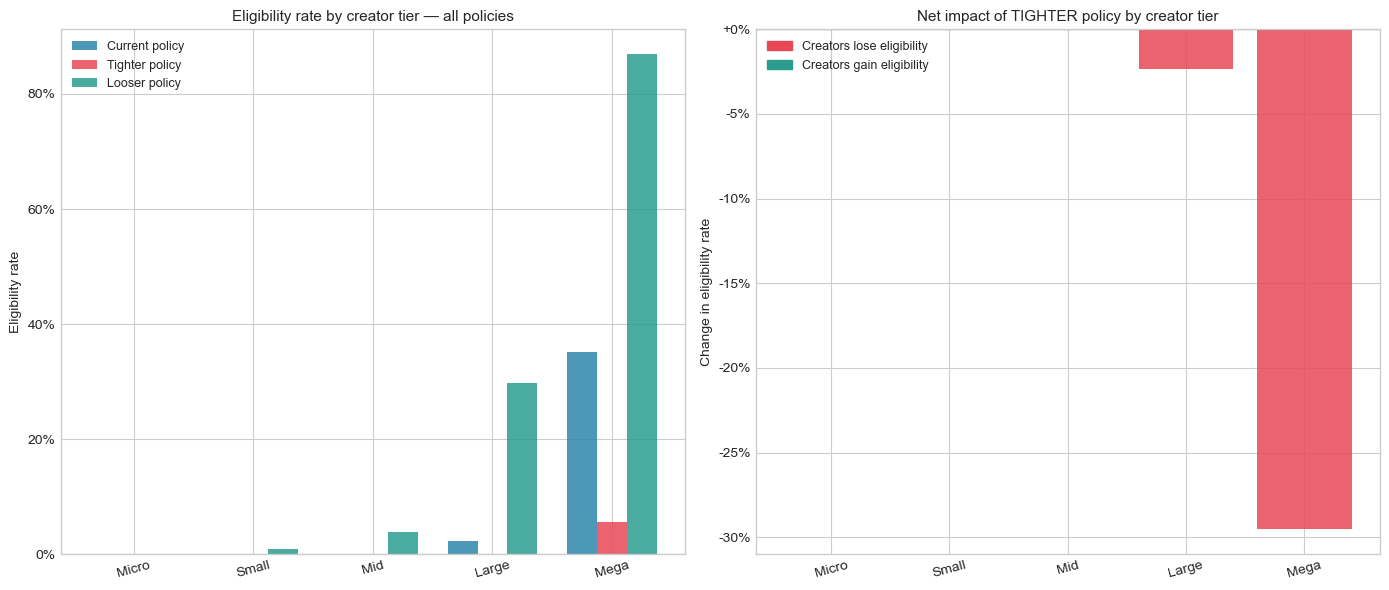


Key insight: which tier is most impacted by the tighter policy?
  → Mega (10M+) creators see the largest eligibility drop
  This is the equity finding — small creators disproportionately affected.


In [6]:
# Visualize segment impact
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(TIER_ORDER))
width = 0.25

# Left: Eligibility rate by tier by policy
ax = axes[0]
for i, (name, cfg) in enumerate(POLICIES.items()):
    col = 'eligible_' + name.split()[0].lower()
    rates = []
    for tier in TIER_ORDER:
        tier_data = creators[creators['creator_tier'] == tier]
        rates.append(tier_data[col].mean() if len(tier_data) > 0 else 0)
    ax.bar(x + (i-1)*width, rates, width, label=name, color=cfg['color'], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([t.split(' ')[0] for t in TIER_ORDER], rotation=15)
ax.set_title('Eligibility rate by creator tier — all policies', fontsize=11)
ax.set_ylabel('Eligibility rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=9)

# Right: Net impact of tighter policy by tier
ax = axes[1]
impacts = []
for tier in TIER_ORDER:
    t = creators[creators['creator_tier'] == tier]
    current  = t['eligible_current'].mean()  if len(t) > 0 else 0
    tighter  = t['eligible_tighter'].mean()  if len(t) > 0 else 0
    impacts.append(tighter - current)

colors = ['#E84855' if v < 0 else '#2A9D8F' for v in impacts]
ax.bar(TIER_ORDER, impacts, color=colors, alpha=0.85)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xticklabels([t.split(' ')[0] for t in TIER_ORDER], rotation=15)
ax.set_title('Net impact of TIGHTER policy by creator tier', fontsize=11)
ax.set_ylabel('Change in eligibility rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:+.0%}'))

red_patch   = mpatches.Patch(color='#E84855', label='Creators lose eligibility')
green_patch = mpatches.Patch(color='#2A9D8F', label='Creators gain eligibility')
ax.legend(handles=[red_patch, green_patch], fontsize=9)

plt.tight_layout()
plt.savefig('/Applications/Studyyy/Projects/Trust and Safety/Creator policy impact simulator/dashboard/screenshots/segment_impact.png', dpi=150)
plt.show()

print('\nKey insight: which tier is most impacted by the tighter policy?')
most_impacted = TIER_ORDER[np.argmin(impacts)]
print(f'  → {most_impacted} creators see the largest eligibility drop')
print('  This is the equity finding — small creators disproportionately affected.')

## 5. Precision / Recall Analysis — The Core T&S Tradeoff

**This is the most important section for your interview.**

We define:
- **True positive:** A genuinely high-quality creator who is correctly deemed eligible
- **False positive:** A borderline/low-quality creator wrongly deemed eligible
- **False negative:** A genuinely high-quality creator wrongly excluded

We use `engagement_rate` in the top quartile as a proxy for "genuinely high quality" — our ground truth label.

Then we compute precision and recall at every threshold and plot the curve.

In [7]:
# Define ground truth: top 40% engagement rate = genuinely high quality
quality_threshold = creators['engagement_rate'].quantile(0.60)
creators['is_high_quality'] = (creators['engagement_rate'] >= quality_threshold).astype(int)

print(f'Ground truth threshold (60th pct engagement): {quality_threshold:.4f}')
print(f'High quality creators: {creators["is_high_quality"].sum():,} ({creators["is_high_quality"].mean():.1%})')

# Compute precision / recall across full threshold range
thresholds = np.arange(0.05, 0.95, 0.025)
pr_rows = []

for t in thresholds:
    preds = (creators['eligibility_score'] >= t).astype(int)
    y_true = creators['is_high_quality']

    tp = ((preds == 1) & (y_true == 1)).sum()
    fp = ((preds == 1) & (y_true == 0)).sum()
    fn = ((preds == 0) & (y_true == 1)).sum()
    tn = ((preds == 0) & (y_true == 0)).sum()

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    fpr       = fp / (fp + tn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    pr_rows.append({
        'threshold':  round(t, 3),
        'precision':  round(precision, 4),
        'recall':     round(recall, 4),
        'fpr':        round(fpr, 4),
        'f1':         round(f1, 4),
        'eligible_pct': round(preds.mean(), 4),
        'fp_count':   int(fp),
        'fn_count':   int(fn),
    })

pr_df = pd.DataFrame(pr_rows)

# Show key thresholds
key_thresholds = [0.25, 0.35, 0.50]
print('\nPrecision / Recall at Key Policy Thresholds:')
print(pr_df[pr_df['threshold'].isin(key_thresholds)][
    ['threshold','precision','recall','fpr','f1','eligible_pct','fp_count','fn_count']
].to_string(index=False))

Ground truth threshold (60th pct engagement): 0.0354
High quality creators: 861 (40.0%)

Precision / Recall at Key Policy Thresholds:
 threshold  precision  recall    fpr     f1  eligible_pct  fp_count  fn_count
      0.25     0.6075  0.5842 0.2515 0.5956        0.3846       325       358
      0.35     0.6269  0.1893 0.0751 0.2908        0.1208        97       698
      0.50     0.3846  0.0174 0.0186 0.0333        0.0181        24       846


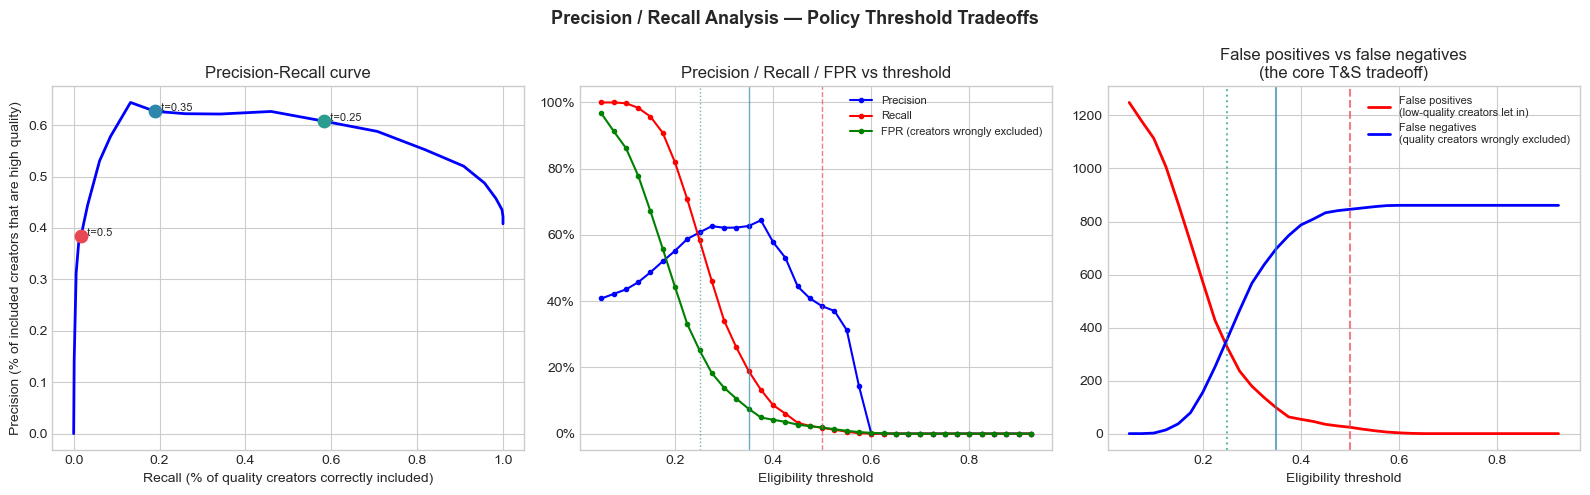


Key finding:
  Current policy (t=0.35): Precision=62.7%, Recall=18.9%, FPR=7.5%
  Tighter policy (t=0.50): Precision=38.5%, Recall=1.7%, FPR=1.9%

  Tightening raises precision (fewer wrong inclusions)
  BUT lowers recall (more quality creators wrongly excluded)
  This is the tradeoff the policy team must decide on.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Precision / Recall Analysis — Policy Threshold Tradeoffs', fontsize=13, fontweight='bold')

# 1. Precision-Recall curve
ax = axes[0]
ax.plot(pr_df['recall'], pr_df['precision'], 'b-', linewidth=2)
for t, cfg in [(0.25, POLICIES['Looser policy']),
               (0.35, POLICIES['Current policy']),
               (0.50, POLICIES['Tighter policy'])]:
    row = pr_df[pr_df['threshold'] == t].iloc[0]
    ax.scatter(row['recall'], row['precision'], color=cfg['color'], s=80, zorder=5)
    ax.annotate(f"  t={t}", (row['recall'], row['precision']), fontsize=8)
ax.set_xlabel('Recall (% of quality creators correctly included)')
ax.set_ylabel('Precision (% of included creators that are high quality)')
ax.set_title('Precision-Recall curve')

# 2. Threshold vs Precision and Recall
ax = axes[1]
ax.plot(pr_df['threshold'], pr_df['precision'], 'b-o', ms=3, label='Precision')
ax.plot(pr_df['threshold'], pr_df['recall'],    'r-o', ms=3, label='Recall')
ax.plot(pr_df['threshold'], pr_df['fpr'],       'g-o', ms=3, label='FPR (creators wrongly excluded)')
for t, cfg in [(0.25, POLICIES['Looser policy']),
               (0.35, POLICIES['Current policy']),
               (0.50, POLICIES['Tighter policy'])]:
    ax.axvline(x=t, color=cfg['color'], linestyle=cfg['linestyle'], alpha=0.7, linewidth=1)
ax.set_xlabel('Eligibility threshold')
ax.set_title('Precision / Recall / FPR vs threshold')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# 3. False Positive and False Negative counts
ax = axes[2]
ax.plot(pr_df['threshold'], pr_df['fp_count'], 'r-', linewidth=2, label='False positives\n(low-quality creators let in)')
ax.plot(pr_df['threshold'], pr_df['fn_count'], 'b-', linewidth=2, label='False negatives\n(quality creators wrongly excluded)')
for t, cfg in [(0.25, POLICIES['Looser policy']),
               (0.35, POLICIES['Current policy']),
               (0.50, POLICIES['Tighter policy'])]:
    ax.axvline(x=t, color=cfg['color'], linestyle=cfg['linestyle'], alpha=0.7)
ax.set_xlabel('Eligibility threshold')
ax.set_title('False positives vs false negatives\n(the core T&S tradeoff)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/Applications/Studyyy/Projects/Trust and Safety/Creator policy impact simulator/dashboard/screenshots/precision_recall.png', dpi=150)
plt.show()

print('\nKey finding:')
row_current = pr_df[pr_df['threshold'] == 0.35].iloc[0]
row_tighter = pr_df[pr_df['threshold'] == 0.50].iloc[0]
print(f'  Current policy (t=0.35): Precision={row_current["precision"]:.1%}, Recall={row_current["recall"]:.1%}, FPR={row_current["fpr"]:.1%}')
print(f'  Tighter policy (t=0.50): Precision={row_tighter["precision"]:.1%}, Recall={row_tighter["recall"]:.1%}, FPR={row_tighter["fpr"]:.1%}')
print(f'\n  Tightening raises precision (fewer wrong inclusions)')
print(f'  BUT lowers recall (more quality creators wrongly excluded)')
print(f'  This is the tradeoff the policy team must decide on.')

## 6. Logistic Regression — What Predicts Eligibility?

Run a logistic regression to find which features most strongly predict whether a creator clears the current eligibility threshold. This mirrors your Ducks churn model — same model, different outcome variable.

Logistic Regression — Predicting YPP Eligibility
AUC: 0.999

              precision    recall  f1-score   support

Not eligible       1.00      0.97      0.99       379
    Eligible       0.83      1.00      0.90        52

    accuracy                           0.97       431
   macro avg       0.91      0.99      0.94       431
weighted avg       0.98      0.97      0.98       431



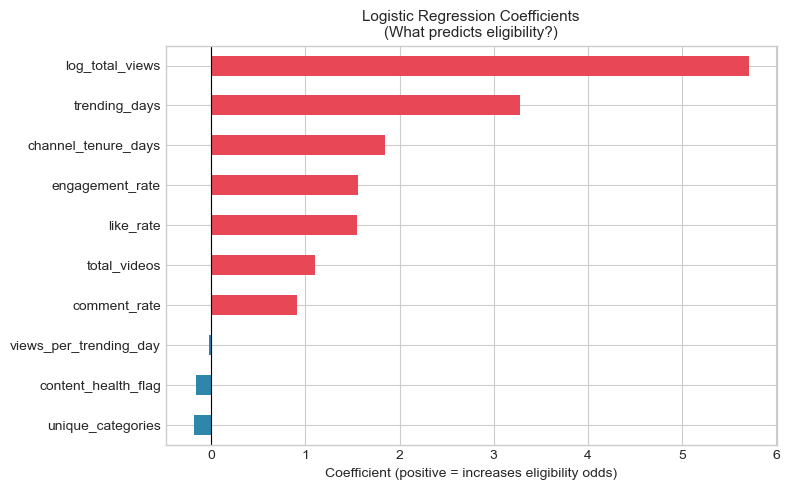


Top 3 positive predictors (increase eligibility odds):
log_total_views        5.709615
trending_days          3.279731
channel_tenure_days    1.845196

Top 3 negative predictors (decrease eligibility odds):
unique_categories        -0.189111
content_health_flag      -0.157325
views_per_trending_day   -0.021778


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

FEATURES = [
    'log_total_views', 'like_rate', 'comment_rate',
    'engagement_rate', 'trending_days', 'total_videos',
    'channel_tenure_days', 'content_health_flag',
    'views_per_trending_day', 'unique_categories'
]

TARGET = 'eligible_current'

avail = [f for f in FEATURES if f in creators.columns]
X = creators[avail].copy()
y = creators[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   LogisticRegression(class_weight='balanced', max_iter=500, random_state=42))
])

pipe.fit(X_train, y_train)
y_prob = pipe.predict_proba(X_test)[:, 1]
y_pred = pipe.predict(X_test)

print(f'Logistic Regression — Predicting YPP Eligibility')
print(f'AUC: {roc_auc_score(y_test, y_prob):.3f}\n')
print(classification_report(y_test, y_pred, target_names=['Not eligible', 'Eligible']))

# Feature coefficients
coefs = pd.Series(
    pipe.named_steps['model'].coef_[0], index=avail
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#E84855' if v > 0 else '#2E86AB' for v in coefs.values]
coefs.plot(kind='barh', color=colors)
plt.title('Logistic Regression Coefficients\n(What predicts eligibility?)', fontsize=11)
plt.xlabel('Coefficient (positive = increases eligibility odds)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('/Applications/Studyyy/Projects/Trust and Safety/Creator policy impact simulator/dashboard/screenshots/lr_coefficients.png', dpi=150)
plt.show()

print('\nTop 3 positive predictors (increase eligibility odds):')
print(coefs.tail(3).sort_values(ascending=False).to_string())
print('\nTop 3 negative predictors (decrease eligibility odds):')
print(coefs.head(3).to_string())

In [11]:
# Save precision/recall table for dashboard
pr_df.to_csv('/Applications/Studyyy/Projects/Trust and Safety/Creator policy impact simulator/data/processed/precision_recall_curve.csv', index=False)
print('Saved precision_recall_curve.csv')

# Save creators with all policy flags
creators.to_csv('/Applications/Studyyy/Projects/Trust and Safety/Creator policy impact simulator/data/processed/creators_with_policies.csv', index=False)
print('Saved creators_with_policies.csv')
print('\nNext → 03_ab_test_analysis.ipynb')

Saved precision_recall_curve.csv
Saved creators_with_policies.csv

Next → 03_ab_test_analysis.ipynb
